# TD3 Self-Driving Car - Google Colab Demo

This notebook is a beginner-friendly, end-to-end Colab workflow for the TD3 car project.

It is compatible with both:
- Google Colab (recommended)
- Local notebook execution (for debugging)

What this notebook does:
1. Locate or clone the repository
2. Install dependencies from requirements.txt
3. Verify headless + GPU environment
4. Run a headless demo and show a preview image inline
5. Optionally run short training, evaluation, and a quick experiment validation

## 1. Locate or clone repository

This cell supports both Colab and local execution:
- If the project already exists, it uses it.
- Otherwise, it clones from GitHub.
- Then it switches into the project directory and validates key files.

In [4]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/adityagangwani30/TD3-Car-Game.git"
DEFAULT_REPO_NAME = "TD3-Car-Game"

def resolve_project_dir() -> Path:
    cwd = Path.cwd()

    # Case 1: already inside the repo
    if (cwd / "main.py").exists() and (cwd / "requirements.txt").exists():
        return cwd

    # Case 2: local workspace has repo folder
    local_candidate = cwd / DEFAULT_REPO_NAME
    if (local_candidate / "main.py").exists():
        return local_candidate

    # Case 3: Colab default path
    colab_base = Path("/content")
    colab_candidate = colab_base / DEFAULT_REPO_NAME
    if colab_candidate.exists():
        return colab_candidate

    # Clone into /content on Colab, otherwise into current working directory
    clone_parent = colab_base if colab_base.exists() else cwd
    target = clone_parent / DEFAULT_REPO_NAME
    if not target.exists():
        print(f"Cloning repository to: {target}")
        subprocess.run(["git", "clone", REPO_URL, str(target)], check=True)
    return target

PROJECT_DIR = resolve_project_dir()
os.chdir(PROJECT_DIR)

required_files = ["main.py", "requirements.txt", "run_experiments.py", "environment.py"]
missing = [f for f in required_files if not (PROJECT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f"Missing required files in project directory: {missing}")

print("Current directory:", Path.cwd())
print("Detected project directory:", PROJECT_DIR)
print("Top-level files:", sorted([p.name for p in PROJECT_DIR.iterdir()])[:20])

Current directory: d:\Mini Project\td3-car-game
Detected project directory: d:\Mini Project\td3-car-game
Top-level files: ['.git', '.gitignore', 'README.md', 'TD3-Car-Game', '__pycache__', 'assets', 'car.py', 'colab_demo.ipynb', 'config.py', 'environment.py', 'eval_models.py', 'lap_timer.py', 'logs', 'main.py', 'metrics_tracker.py', 'models', 'plot_metrics.py', 'replay_buffer.py', 'requirements.txt', 'run_experiments.py']


## 2. Install dependencies

Installs all project dependencies from requirements.txt, then verifies core imports used in training and visualization.

In [5]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])

# Import verification
import numpy
import pygame
import torch

print("Dependency check passed")
print("numpy:", numpy.__version__)
print("pygame:", pygame.__version__)
print("torch:", torch.__version__)

d:\Mini Project\td3-car-game\venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.13.7)
Hello from the pygame community. https://www.pygame.org/contribute.html
Dependency check passed
numpy: 2.4.4
pygame: 2.6.1
torch: 2.11.0+cpu


## 3. Configure headless mode and verify runtime

Colab is headless, so we force SDL to dummy drivers before running simulation code.

This cell also validates:
- GPU availability
- key project imports
- asset generation readiness

In [6]:
import os
from pathlib import Path

# Force safe headless behavior in Colab/notebook environments
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")
os.environ.setdefault("SDL_AUDIODRIVER", "dummy")

import torch
from utils import detect_headless_environment, ensure_assets_exist

device = "cuda" if torch.cuda.is_available() else "cpu"
headless_detected = detect_headless_environment()

ensure_assets_exist()

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Using device:", device)
print("Headless detected:", headless_detected)
print("Working directory:", Path.cwd())
print("Assets directory exists:", Path("assets").exists())

PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu
Headless detected: False
Working directory: d:\Mini Project\td3-car-game
Assets directory exists: True


## 4. Run headless demo and show preview

Runs demo mode with explicit `--headless` to avoid window creation.

After execution, the notebook displays the generated preview image (`logs/demo_preview.png`).

## 4b. Optional fallback preview generation

If the demo does not create a preview image, this cell creates one frame directly from the environment and saves it as PNG.

Running demo in headless mode...
Preview available: logs\demo_preview.png


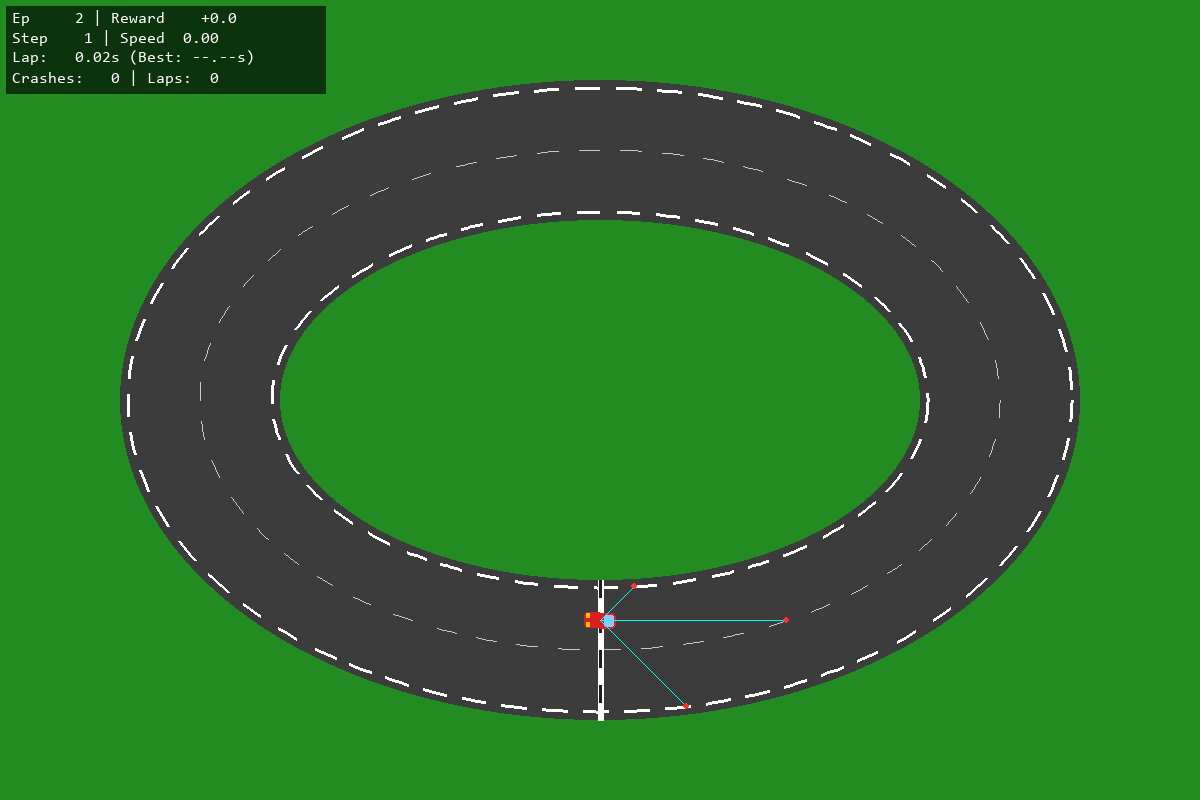

In [7]:
import subprocess
import sys
from pathlib import Path

from IPython.display import Image, display

preview_path = Path("logs/demo_preview.png")
preview_path.parent.mkdir(parents=True, exist_ok=True)

print("Running demo in headless mode...")
subprocess.run([
    sys.executable,
    "main.py",
    "--mode", "demo",
    "--demo-episodes", "2",
    "--headless",
], check=True)

if not preview_path.exists():
    print("Demo preview not found. Generating fallback preview frame...")
    import pygame
    from environment import CarRacingEnv
    from utils import init_pygame

    init_pygame(headless=True)
    env = CarRacingEnv(headless=True, enable_metrics=False)
    env.reset()
    env.render()
    pygame.image.save(env.screen, str(preview_path))
    env.close()
    pygame.quit()

if preview_path.exists():
    print(f"Preview available: {preview_path}")
    display(Image(filename=str(preview_path)))
else:
    raise FileNotFoundError("Preview image was not generated.")

## 5. Optional: short training, evaluation, and experiment validation

These optional cells run very small jobs to verify end-to-end compatibility with the current codebase:
- short training (`main.py --mode train`)
- short evaluation (`main.py --mode eval`)
- quick experiment framework check (`run_experiments.py`)

All commands use `--headless` so they are safe in Colab.

In [8]:
import subprocess
import sys

print("Running short headless training sanity check...")
subprocess.run([
    sys.executable, "main.py",
    "--mode", "train",
    "--headless",
    "--max-episodes", "1",
    "--max-steps", "25",
], check=True)
print("Short training completed.")

Running short headless training sanity check...
Short training completed.


In [9]:
import subprocess
import sys

print("Running short headless evaluation sanity check...")
subprocess.run([
    sys.executable, "main.py",
    "--mode", "eval",
    "--headless",
    "--eval-episodes", "1",
], check=True)
print("Short evaluation completed.")

Running short headless evaluation sanity check...
Short evaluation completed.


In [10]:
import subprocess
import sys
from pathlib import Path

print("Running quick run_experiments.py validation...")
subprocess.run([
    sys.executable, "run_experiments.py",
    "--headless",
    "--max-experiments", "1",
    "--max-episodes", "1",
    "--max-steps", "20",
], check=True)

# Confirm expected output directories
logs_dir = Path("logs")
models_dir = Path("models")
print("logs exists:", logs_dir.exists())
print("models exists:", models_dir.exists())
print("Sample logs subdirs:", [p.name for p in sorted(logs_dir.iterdir())[:5]] if logs_dir.exists() else [])
print("Sample models subdirs:", [p.name for p in sorted(models_dir.iterdir())[:5]] if models_dir.exists() else [])
print("Experiment framework validation completed.")

Running quick run_experiments.py validation...
logs exists: True
models exists: True
Sample logs subdirs: ['demo_preview.png', 'R1_N1', 'training_log.jsonl']
Sample models subdirs: ['R1_N1', 'td3_best.pth', 'td3_best_avg100.pth']
Experiment framework validation completed.
